# TA_Data Mining_Shayan Rokhva_Dr. Dehghan_12 Nov 2025_.ipynb

## Inits

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset => Medical Cost Personal (Kaggle)

In [32]:
path = "/content/drive/MyDrive/MedicalCostPersonalDataset.csv"

In [33]:
df = pd.read_csv("/content/drive/MyDrive/MedicalCostPersonalDataset.csv")

In [34]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Categorical features represent qualitative data:


Nominal: unordered categories (e.g., gender, region).


Ordinal: ordered categories (e.g., education level, satisfaction).


Numerical features represent quantitative data:


Discrete: countable integers (e.g., number of children).


Continuous: measurable values with decimals (e.g., age, BMI, income).



Categorical Features (Qualitative)


Nominal:


sex → unordered labels (male/female).


smoker → binary, no order (yes/no).


region → geographic categories, no inherent order (northeast, southwest, etc.).




(No ordinal features — none have ranked categories.)

Numerical Features (Quantitative)


Discrete:


children → integer count of dependents.




Continuous:


age → measurable variable, can take any value within range.


bmi → continuous measurement of body mass index.


charges → continuous, monetary healthcare cost.





✅ Summary:


Nominal: sex, smoker, region


Discrete: children


Continuous: age, bmi, charges



## Statistical & Data Analysis

### Overall

In [13]:
import pandas as pd
import numpy as np

# --- Simple Statistical Summary for All Features ---
summary = pd.DataFrame({
    'Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Q1 (25%)': df.quantile(0.25, numeric_only=True),
    'Q3 (75%)': df.quantile(0.75, numeric_only=True),
    'Variance': df.var(numeric_only=True),
    'Standard Deviation': df.std(numeric_only=True)
})

# --- Fill non-numeric features with NaN for numeric stats ---
summary = summary.round(3)

print("📊 Simple Statistical Summary of All Features:\n")
display(summary)


📊 Simple Statistical Summary of All Features:



,Count,Missing Values,Mean,Median,Q1 (25%),Q3 (75%),Variance,Standard Deviation
age,1338,0,39.207,39.000,27.000,51.000,1.974010e+02,14.050
bmi,1338,0,30.663,30.400,26.296,34.694,3.718800e+01,6.098
charges,1338,0,13270.422,9382.033,4740.287,16639.913,1.466524e+08,12110.011
children,1338,0,1.095,1.000,0.000,2.000,1.453000e+00,1.205
region,1338,0,NaN,NaN,NaN,NaN,NaN,NaN
sex,1338,0,NaN,NaN,NaN,NaN,NaN,NaN
smoker,1338,0,NaN,NaN,NaN,NaN,NaN,NaN


### Age

Descriptive Statistics for Age:
 count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

Mode of Age: 18
Variance: 197.40138665754424
Standard Deviation: 14.049960379216172
Skewness: 0.05567251565299186
Kurtosis: -1.2450876526418673


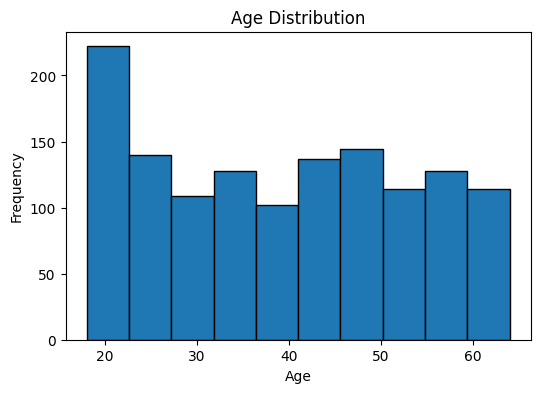

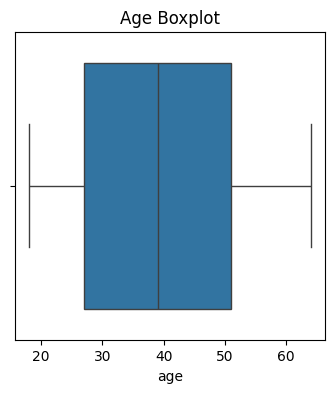


Correlation between Age and Charges: 0.299


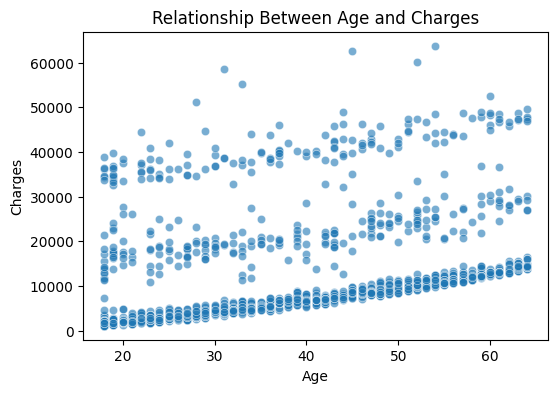

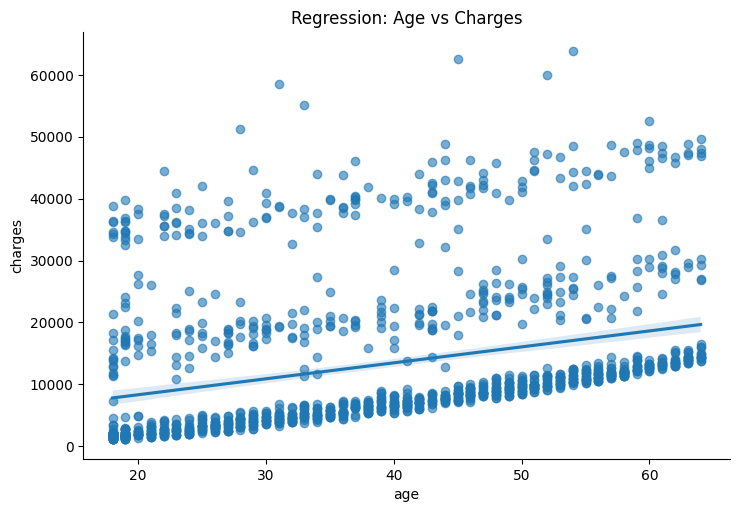

In [6]:
# Age

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Basic Descriptive Statistics ---
print("Descriptive Statistics for Age:\n", df['age'].describe())

# --- Additional Measures ---
print("\nMode of Age:", df['age'].mode()[0])
print("Variance:", df['age'].var())
print("Standard Deviation:", df['age'].std())
print("Skewness:", df['age'].skew())
print("Kurtosis:", df['age'].kurt())

# --- Histogram ---
plt.figure(figsize=(6,4))
plt.hist(df['age'], bins=10, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# --- Boxplot to Check Outliers ---
plt.figure(figsize=(4,4))
sns.boxplot(x=df['age'])
plt.title('Age Boxplot')
plt.show()

# --- Correlation with Charges ---
corr = df['age'].corr(df['charges'])
print(f"\nCorrelation between Age and Charges: {corr:.3f}")

# --- Scatter Plot (Age vs Charges) ---
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df, alpha=0.6)
plt.title('Relationship Between Age and Charges')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

# --- Regression Line (Moderate Analysis) ---
sns.lmplot(x='age', y='charges', data=df, aspect=1.5, scatter_kws={'alpha':0.6})
plt.title('Regression: Age vs Charges')
plt.show()


### Sex

Frequency of each gender:
 sex
male      676
female    662
Name: count, dtype: int64

Proportion of each gender:
 sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64


/tmp/ipython-input-2698363698.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='Set2')


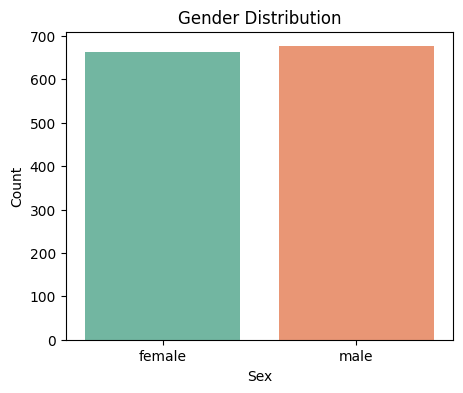


Mean healthcare charges by gender:
 sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64


/tmp/ipython-input-2698363698.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='charges', data=df, palette='coolwarm')


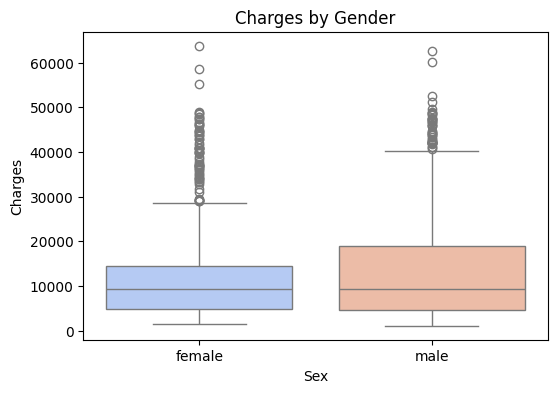


T-test Results (Male vs Female Charges):
T-statistic = 2.101, P-value = 0.0358
→ Significant difference between male and female charges.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Frequency Counts (Simple Analysis) ---
print("Frequency of each gender:\n", df['sex'].value_counts())

# --- Proportion of Each Category ---
print("\nProportion of each gender:\n", df['sex'].value_counts(normalize=True))

# --- Bar Plot for Gender Distribution ---
plt.figure(figsize=(5,4))
sns.countplot(x='sex', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

# --- Mean Healthcare Charges per Gender (Moderate Analysis) ---
mean_charges_by_sex = df.groupby('sex')['charges'].mean()
print("\nMean healthcare charges by gender:\n", mean_charges_by_sex)

# --- Boxplot to Compare Charges by Gender ---
plt.figure(figsize=(6,4))
sns.boxplot(x='sex', y='charges', data=df, palette='coolwarm')
plt.title('Charges by Gender')
plt.xlabel('Sex')
plt.ylabel('Charges')
plt.show()

# --- Independent T-test (Moderate Analysis) ---
male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']
t_stat, p_value = stats.ttest_ind(male_charges, female_charges, equal_var=False)

print(f"\nT-test Results (Male vs Female Charges):\nT-statistic = {t_stat:.3f}, P-value = {p_value:.4f}")
if p_value < 0.05:
    print("→ Significant difference between male and female charges.")
else:
    print("→ No significant difference between male and female charges.")


### BMI

Descriptive Statistics for BMI:
 count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

Mode of BMI: 32.3
Variance: 37.187883609773266
Standard Deviation: 6.098186911679017
Skewness: 0.2840471105987448
Kurtosis: -0.05073153135467834


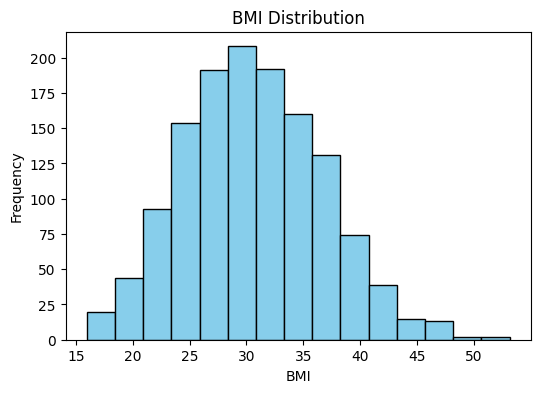

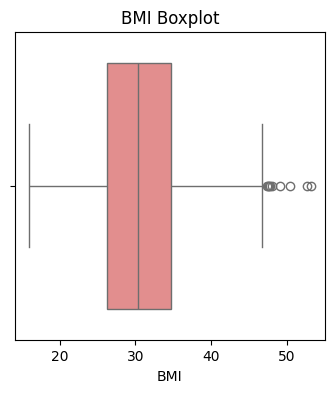


Correlation between BMI and Charges: 0.198


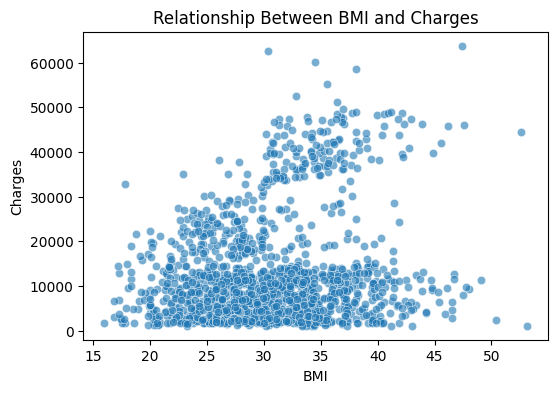

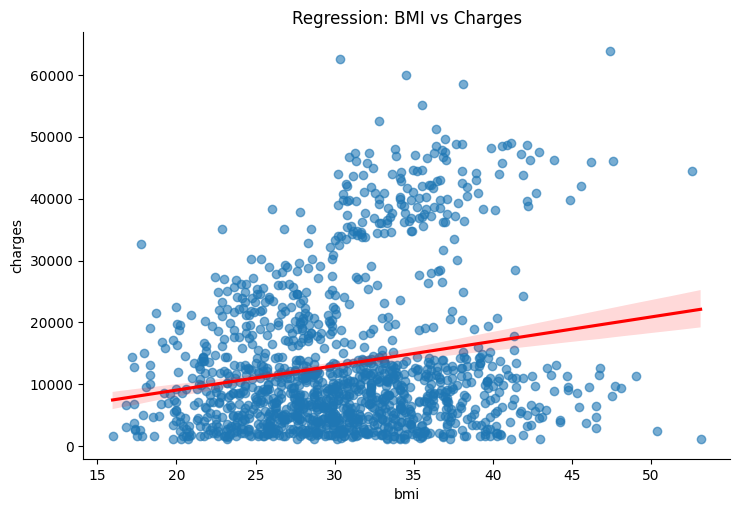

/tmp/ipython-input-1519158900.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='bmi', data=df, palette='coolwarm')


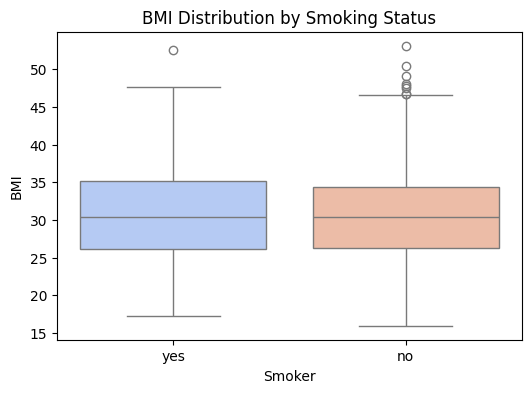

Correlation between BMI and Age: 0.109


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Basic Descriptive Statistics ---
print("Descriptive Statistics for BMI:\n", df['bmi'].describe())

# --- Additional Measures ---
print("\nMode of BMI:", df['bmi'].mode()[0])
print("Variance:", df['bmi'].var())
print("Standard Deviation:", df['bmi'].std())
print("Skewness:", df['bmi'].skew())
print("Kurtosis:", df['bmi'].kurt())

# --- Histogram (Distribution of BMI) ---
plt.figure(figsize=(6,4))
plt.hist(df['bmi'], bins=15, color='skyblue', edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

# --- Boxplot to Detect Outliers ---
plt.figure(figsize=(4,4))
sns.boxplot(x=df['bmi'], color='lightcoral')
plt.title('BMI Boxplot')
plt.xlabel('BMI')
plt.show()

# --- Correlation with Charges (Moderate Analysis) ---
corr_bmi_charges = df['bmi'].corr(df['charges'])
print(f"\nCorrelation between BMI and Charges: {corr_bmi_charges:.3f}")

# --- Scatter Plot: BMI vs Charges ---
plt.figure(figsize=(6,4))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.6)
plt.title('Relationship Between BMI and Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.show()

# --- Regression Line: BMI vs Charges ---
sns.lmplot(x='bmi', y='charges', data=df, aspect=1.5, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regression: BMI vs Charges')
plt.show()

# --- Grouped Analysis by Smoker (Moderate Insight) ---
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='bmi', data=df, palette='coolwarm')
plt.title('BMI Distribution by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('BMI')
plt.show()

# --- Correlation between BMI and Age (Extra Moderate Insight) ---
corr_bmi_age = df['bmi'].corr(df['age'])
print(f"Correlation between BMI and Age: {corr_bmi_age:.3f}")


### Children

Descriptive Statistics for Children:
 count    1338.000000
mean        1.094918
std         1.205493
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

Mode: 0
Variance: 1.4532127456668944
Standard Deviation: 1.2054927397819095

Frequency of Each Value:
 children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


/tmp/ipython-input-3127601924.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='children', data=df, palette='pastel')


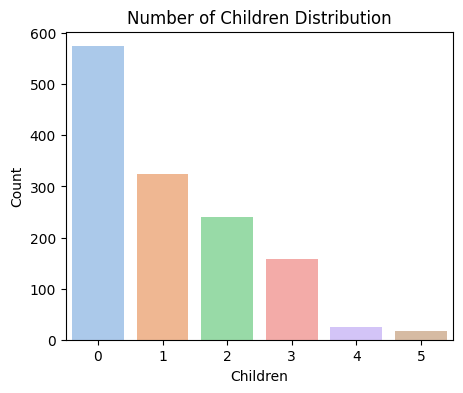

/tmp/ipython-input-3127601924.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='children', y='charges', data=df, palette='coolwarm')


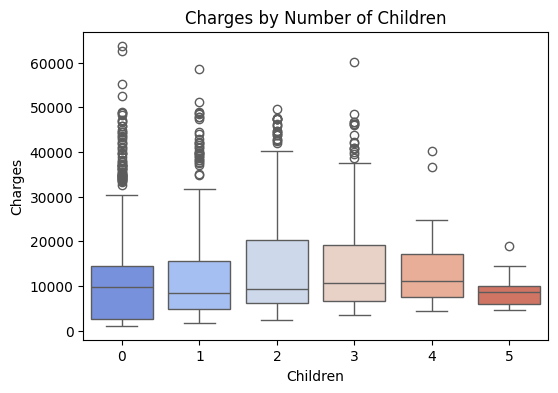


ANOVA Result: F-stat = 3.297, P-value = 0.0058
→ Significant difference in charges based on number of children.


In [9]:
# --- Descriptive Statistics for 'children' ---
print("Descriptive Statistics for Children:\n", df['children'].describe())
print("\nMode:", df['children'].mode()[0])
print("Variance:", df['children'].var())
print("Standard Deviation:", df['children'].std())

# --- Frequency Table ---
print("\nFrequency of Each Value:\n", df['children'].value_counts().sort_index())

# --- Bar Plot (Counts) ---
plt.figure(figsize=(5,4))
sns.countplot(x='children', data=df, palette='pastel')
plt.title('Number of Children Distribution')
plt.xlabel('Children')
plt.ylabel('Count')
plt.show()

# --- Boxplot for Charges by Children ---
plt.figure(figsize=(6,4))
sns.boxplot(x='children', y='charges', data=df, palette='coolwarm')
plt.title('Charges by Number of Children')
plt.xlabel('Children')
plt.ylabel('Charges')
plt.show()

# --- ANOVA: Does number of children affect charges? ---
groups = [df[df['children'] == n]['charges'] for n in df['children'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA Result: F-stat = {f_stat:.3f}, P-value = {p_value:.4f}")
if p_value < 0.05:
    print("→ Significant difference in charges based on number of children.")
else:
    print("→ No significant difference in charges based on number of children.")


### Smoker

Frequency of Smoker Status:
 smoker
no     1064
yes     274
Name: count, dtype: int64

Proportion of Smoker Status:
 smoker
no     0.795217
yes    0.204783
Name: proportion, dtype: float64


/tmp/ipython-input-2226965583.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, palette='Set2')


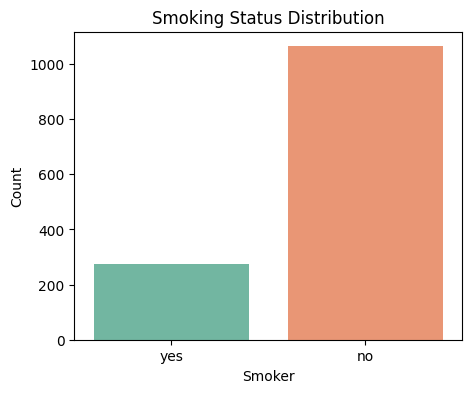


Mean Charges by Smoker Status:
 smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64


/tmp/ipython-input-2226965583.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='coolwarm')


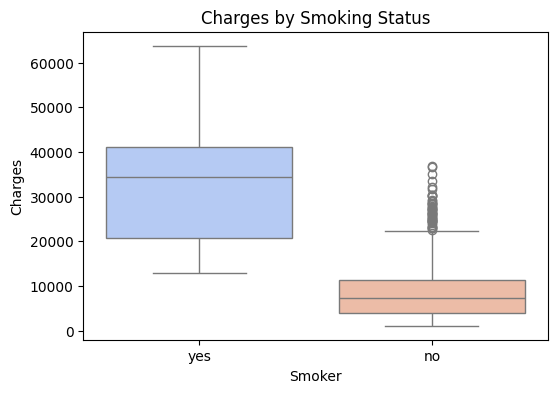


T-test Results: T-stat = 32.752, P-value = 0.000000
→ Significant difference in charges between smokers and non-smokers.


In [10]:
# --- Frequency and Proportion ---
print("Frequency of Smoker Status:\n", df['smoker'].value_counts())
print("\nProportion of Smoker Status:\n", df['smoker'].value_counts(normalize=True))

# --- Bar Plot ---
plt.figure(figsize=(5,4))
sns.countplot(x='smoker', data=df, palette='Set2')
plt.title('Smoking Status Distribution')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

# --- Mean Charges by Smoker Status ---
mean_charges_smoker = df.groupby('smoker')['charges'].mean()
print("\nMean Charges by Smoker Status:\n", mean_charges_smoker)

# --- Boxplot for Charges by Smoker ---
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df, palette='coolwarm')
plt.title('Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

# --- Independent T-test (Smoker vs Non-Smoker) ---
smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']
t_stat, p_value = stats.ttest_ind(smoker_charges, nonsmoker_charges, equal_var=False)

print(f"\nT-test Results: T-stat = {t_stat:.3f}, P-value = {p_value:.6f}")
if p_value < 0.05:
    print("→ Significant difference in charges between smokers and non-smokers.")
else:
    print("→ No significant difference in charges between smokers and non-smokers.")


### Region

Frequency of Each Region:
 region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Proportion of Each Region:
 region
southeast    0.272048
southwest    0.242900
northwest    0.242900
northeast    0.242152
Name: proportion, dtype: float64


/tmp/ipython-input-2058794678.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, palette='pastel')


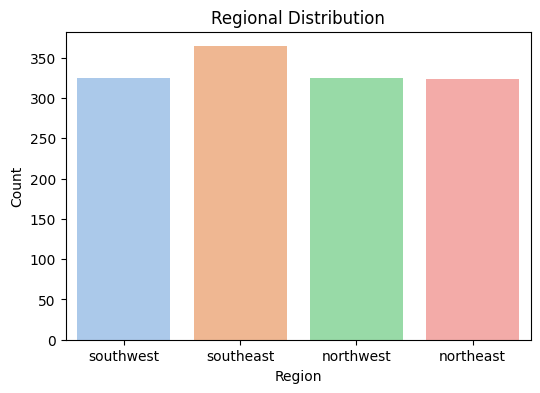


Mean Charges by Region:
 region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


/tmp/ipython-input-2058794678.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='charges', data=df, palette='Set3')


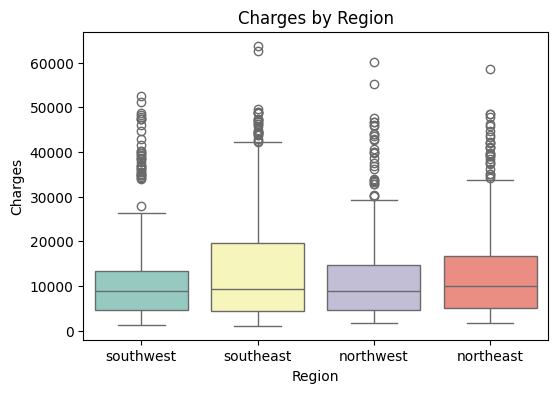


ANOVA Result: F-stat = 2.970, P-value = 0.0309
→ Significant difference in charges across regions.


In [11]:
# --- Frequency Table ---
print("Frequency of Each Region:\n", df['region'].value_counts())

# --- Proportion of Each Region ---
print("\nProportion of Each Region:\n", df['region'].value_counts(normalize=True))

# --- Bar Plot ---
plt.figure(figsize=(6,4))
sns.countplot(x='region', data=df, palette='pastel')
plt.title('Regional Distribution')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

# --- Mean Charges per Region ---
mean_charges_region = df.groupby('region')['charges'].mean()
print("\nMean Charges by Region:\n", mean_charges_region)

# --- Boxplot for Charges by Region ---
plt.figure(figsize=(6,4))
sns.boxplot(x='region', y='charges', data=df, palette='Set3')
plt.title('Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

# --- One-way ANOVA ---
groups = [df[df['region'] == r]['charges'] for r in df['region'].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"\nANOVA Result: F-stat = {f_stat:.3f}, P-value = {p_value:.4f}")
if p_value < 0.05:
    print("→ Significant difference in charges across regions.")
else:
    print("→ No significant difference in charges across regions.")


### Charges

Descriptive Statistics for Charges:
 count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Variance: 146652372.1528548
Standard Deviation: 12110.011236693994
Skewness: 1.5158796580240388
Kurtosis: 1.6062986532967907


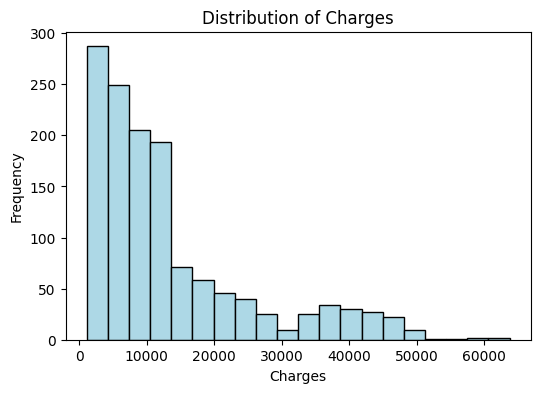

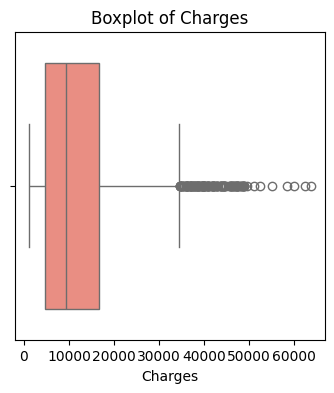


Correlation of Charges with Numerical Features:
 charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64


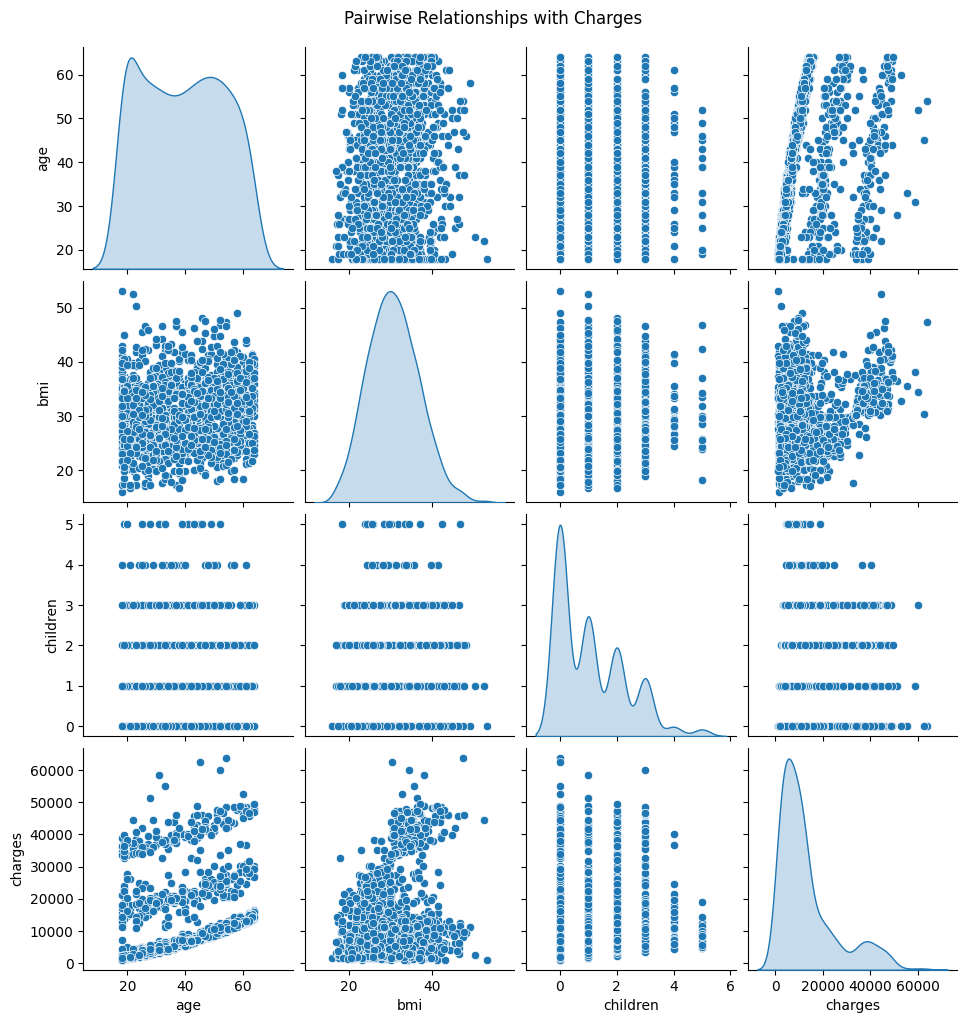

In [12]:
# --- Descriptive Statistics ---
print("Descriptive Statistics for Charges:\n", df['charges'].describe())
print("\nVariance:", df['charges'].var())
print("Standard Deviation:", df['charges'].std())
print("Skewness:", df['charges'].skew())
print("Kurtosis:", df['charges'].kurt())

# --- Histogram ---
plt.figure(figsize=(6,4))
plt.hist(df['charges'], bins=20, color='lightblue', edgecolor='black')
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# --- Boxplot ---
plt.figure(figsize=(4,4))
sns.boxplot(x=df['charges'], color='salmon')
plt.title('Boxplot of Charges')
plt.xlabel('Charges')
plt.show()

# --- Correlation with Other Numerical Features ---
num_features = ['age', 'bmi', 'children']
corrs = df[num_features + ['charges']].corr()['charges'].sort_values(ascending=False)
print("\nCorrelation of Charges with Numerical Features:\n", corrs)

# --- Pairplot for Continuous Features ---
sns.pairplot(df[['age', 'bmi', 'children', 'charges']], diag_kind='kde')
plt.suptitle('Pairwise Relationships with Charges', y=1.02)
plt.show()


## Data Quality

### Completeness (isnull)

In [14]:
df.select_dtypes(include=[np.number]).isnull().sum()


,0
age,0
bmi,0
children,0
charges,0


In [15]:
df.select_dtypes(include=[np.number]).isnull().sum().sort_values(ascending=False)


,0
age,0
bmi,0
children,0
charges,0


### Uniqueness (repetitions)

This will NOT apply on a single columns usually

In [16]:
# ستون مورد نظر (age یا charges)
col = 'age'  # یا 'charges'

# شمارش تکراری‌ها در همان ستون
duplicate_count = df[col].duplicated().sum()

print(f"🔸 تعداد مقادیر تکراری در ستون '{col}': {duplicate_count}")


🔸 تعداد مقادیر تکراری در ستون 'age': 1291


In [17]:
df[col].value_counts()[df[col].value_counts() > 1]


,count
age,
18,69
19,68
46,29
52,29
50,29
47,29
48,29
51,29
45,29


But on the complete dataset

In [18]:
# حذف ستون شناسه (اگر موجود است)
df_no_id = df.drop(columns=['id'], errors='ignore')

# پیدا کردن سطرهای تکراری
duplicates = df_no_id[df_no_id.duplicated(keep=False)]

# نمایش تعداد و شماره (index) سطرهای تکراری
print(f"🔹 تعداد سطرهای کاملاً تکراری (بدون درنظر گرفتن ID): {duplicates.shape[0]}")
print("🔹 شماره سطرهای تکراری:\n", duplicates.index.tolist())


🔹 تعداد سطرهای کاملاً تکراری (بدون درنظر گرفتن ID): 2
🔹 شماره سطرهای تکراری:
 [195, 581]


In [19]:
# 🔹 نمایش دقیق سطرهای تکراری در دیتاست (به جز ستون ID)

df_no_id = df.drop(columns=['id'], errors='ignore')                 # حذف ستون ID اگر وجود دارد
duplicates = df_no_id[df_no_id.duplicated(keep=False)]              # یافتن همه ردیف‌های تکراری
print(f"🔸 تعداد سطرهای تکراری (بدون درنظر گرفتن ID): {duplicates.shape[0]}")
print("🔸 شماره سطرهای تکراری:", duplicates.index.tolist())
print("\n🔹 نمایش دقیق سطرهای تکراری:")
display(df.loc[duplicates.index])                                   # نمایش دقیق خود ردیف‌ها


🔸 تعداد سطرهای تکراری (بدون درنظر گرفتن ID): 2
🔸 شماره سطرهای تکراری: [195, 581]

🔹 نمایش دقیق سطرهای تکراری:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


This should be removed as it can be problematic in analysis

### Consistency & Accuracy

In [20]:
# 🔹 Show value counts for all categorical features

# Select only categorical (object or category dtype) columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Loop through each categorical column and show unique values + counts
for col in categorical_cols:
    print(f"\n🔸 Feature: '{col}'")
    print(df[col].value_counts(dropna=False))



🔸 Feature: 'sex'
sex
male      676
female    662
Name: count, dtype: int64

🔸 Feature: 'smoker'
smoker
no     1064
yes     274
Name: count, dtype: int64

🔸 Feature: 'region'
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [21]:
# 🔹 Check data consistency for 'sex' and 'region'

# Define allowed (valid) values
valid_sex = ['male', 'female']
valid_region = ['northeast', 'northwest', 'southeast', 'southwest']

# Find inconsistent (invalid) entries
invalid_sex = df[~df['sex'].isin(valid_sex)]
invalid_region = df[~df['region'].isin(valid_region)]

# Print summary
print("🔸 Invalid 'sex' entries:", len(invalid_sex))
print("🔸 Invalid 'region' entries:", len(invalid_region))

# Show the problematic rows if any
if not invalid_sex.empty:
    print("\n⚠️ Inconsistent 'sex' values:")
    display(invalid_sex)
if not invalid_region.empty:
    print("\n⚠️ Inconsistent 'region' values:")
    display(invalid_region)


🔸 Invalid 'sex' entries: 0
🔸 Invalid 'region' entries: 0


Other examples of consistency => Age should not be higher than 120 and not even 100 in usuall cases!

In [22]:
# 🔹 Check min and max of age, and flag if any invalid values (>100)
min_age, max_age = df['age'].min(), df['age'].max()
print(f"Minimum age: {min_age}")
print(f"Maximum age: {max_age}")

if max_age > 100:
    print("⚠️ Invalid age detected! Some ages exceed 100.")
else:
    print("✅ All ages are within the valid range (≤100).")


Minimum age: 18
Maximum age: 64
✅ All ages are within the valid range (≤100).


Others (in other domains) => for example the birth day should always be before than the registeration date (e.g.)

Other examples => If a large proportion of a feature’s values (e.g., age) are concentrated around an unrealistic or illogical number — assuming the data were collected under normal conditions — this pattern is suspicious and should be investigated further.

Example: In an app development or UX design context, if most users’ ages (or a signficant portion of them) are recorded as exactly 30, it might indicate a data entry default, form autofill bug, or user reluctance to share real information, rather than a true population pattern.

### **A brief overview**

سؤال خیلی خوبی پرسیدی 🌟
در ارزیابی کیفیت داده (Data Quality)، چند معیار متداول و ساده وجود دارد که تقریباً در همه پروژه‌های داده‌ای بررسی می‌شن:

🔹 ۱. Completeness (کامل بودن)

یعنی آیا همه مقادیر لازم وجود دارند یا داده‌های گمشده داریم؟
👉 معیار ساده: درصد مقادیر NaN یا Null در هر ستون.

🔹 ۲. Uniqueness (یکتا بودن)

آیا مقادیر تکراری وجود دارند؟
👉 معیار ساده: شمارش ردیف‌های تکراری (duplicated) یا IDهای غیر‌منحصربه‌فرد.

🔹 ۳. Consistency (سازگاری)

آیا داده‌ها در بخش‌های مختلف با هم سازگارند؟
👉 مثال: “Sex” فقط شامل male و female باشد، نه Male, FEMALE, M.
👉 یا تاریخ تولد نباید بعد از تاریخ ثبت‌نام باشد.

🔹 ۴. Accuracy (درستی)

آیا داده با واقعیت مطابقت دارد؟
👉 سخت‌تر برای اندازه‌گیری، ولی می‌شود بازه‌های منطقی بررسی کرد:
مثلاً age بین 0 تا 120 باشد یا BMI بین 10 تا 60.

🔹 ۵. Validity (اعتبار)

آیا داده‌ها با قواعد تعریف‌شده سازگارند؟
👉 مثال: کد پستی باید ۵ رقمی باشد، یا متغیر “region” فقط از بین چهار مقدار مجاز باشد.

🔹 ۶. Timeliness (به‌موقع بودن)

آیا داده‌ها به‌روز هستند یا قدیمی؟
👉 مثال: داده‌های سال ۲۰۱۵ ممکن است برای تحلیل فعلی قابل‌اعتماد نباشند.

🔹 ۷. Integrity (یکپارچگی)

آیا ارتباط بین جداول و کلیدهای خارجی (foreign keys) حفظ شده است؟
👉 مثال: هر سفارش باید به یک کاربر موجود در جدول کاربران مربوط باشد.

## Normalizations/Standardization

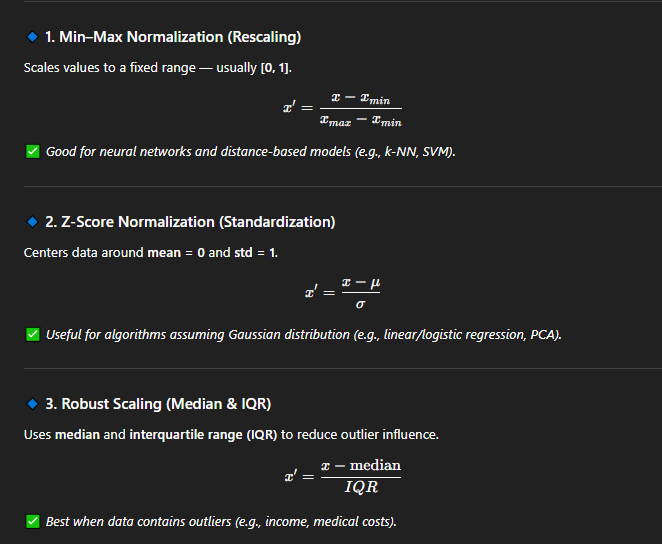

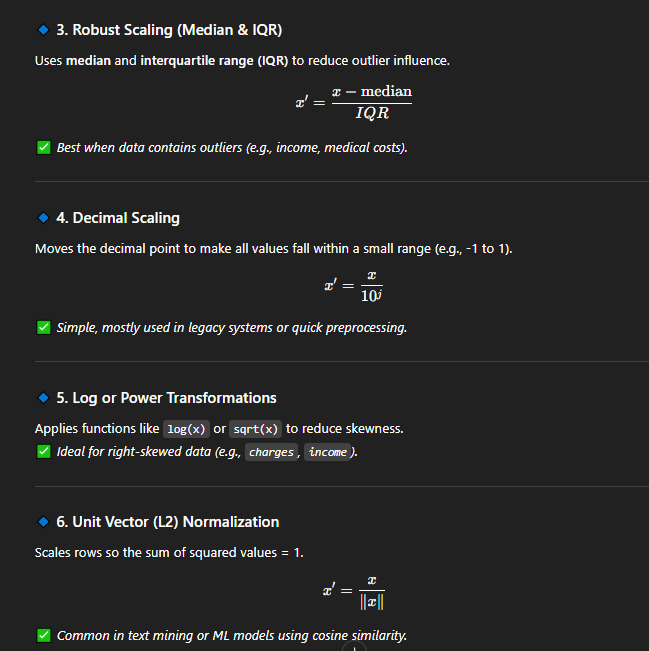

In [25]:
# Min–Max Normalization

from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
df['charges_minmax'] = scaler_minmax.fit_transform(df[['charges']])

print(df[['charges', 'charges_minmax']].head(10))


       charges  charges_minmax
0  16884.92400        0.251611
1   1725.55230        0.009636
2   4449.46200        0.053115
3  21984.47061        0.333010
4   3866.85520        0.043816
5   3756.62160        0.042056
6   8240.58960        0.113629
7   7281.50560        0.098320
8   6406.41070        0.084352
9  28923.13692        0.443765


In [27]:
# Z-Score Normalization (Standardization)

from sklearn.preprocessing import StandardScaler

scaler_zscore = StandardScaler()
df['charges_zscore'] = scaler_zscore.fit_transform(df[['charges']])

print(df[['charges', 'charges_zscore']].head(10))


       charges  charges_zscore
0  16884.92400        0.298584
1   1725.55230       -0.953689
2   4449.46200       -0.728675
3  21984.47061        0.719843
4   3866.85520       -0.776802
5   3756.62160       -0.785908
6   8240.58960       -0.415500
7   7281.50560       -0.494728
8   6406.41070       -0.567017
9  28923.13692        1.293027


In [ ]:
# Robust Scaling (based on Medical and IQR)

In [29]:
from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()
df['charges_robust'] = scaler_robust.fit_transform(df[['charges']])

print(df[['charges', 'charges_robust']].head(10))


       charges  charges_robust
0  16884.92400        0.630515
1   1725.55230       -0.643422
2   4449.46200       -0.414515
3  21984.47061        1.059062
4   3866.85520       -0.463475
5   3756.62160       -0.472739
6   8240.58960       -0.095923
7   7281.50560       -0.176520
8   6406.41070       -0.250060
9  28923.13692        1.642161


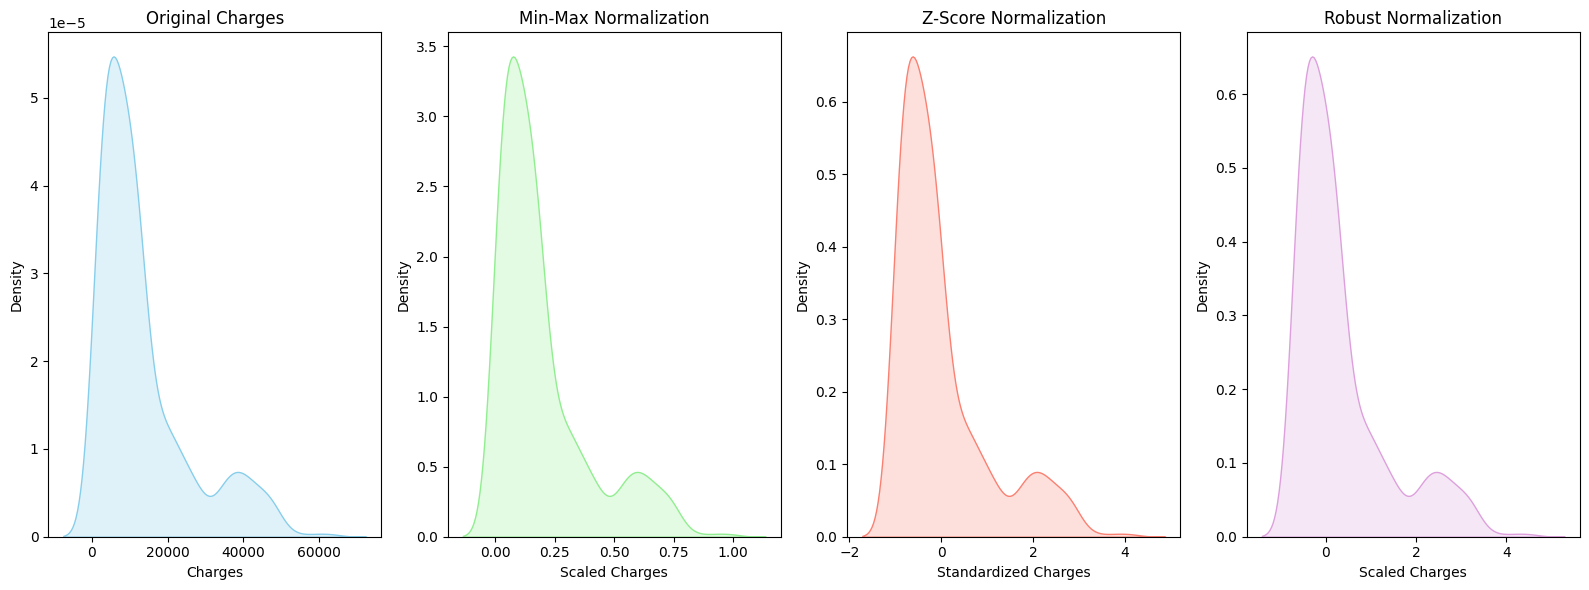

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 6))

# --- Original ---
plt.subplot(1, 4, 1)
sns.kdeplot(df['charges'], fill=True, color='skyblue')
plt.title('Original Charges')
plt.xlabel('Charges')
plt.ylabel('Density')

# --- Min-Max ---
plt.subplot(1, 4, 2)
sns.kdeplot(df['charges_minmax'], fill=True, color='lightgreen')
plt.title('Min-Max Normalization')
plt.xlabel('Scaled Charges')
plt.ylabel('Density')

# --- Z-Score ---
plt.subplot(1, 4, 3)
sns.kdeplot(df['charges_zscore'], fill=True, color='salmon')
plt.title('Z-Score Normalization')
plt.xlabel('Standardized Charges')
plt.ylabel('Density')

# --- Robust ---
plt.subplot(1, 4, 4)
sns.kdeplot(df['charges_robust'], fill=True, color='plum')
plt.title('Robust Normalization')
plt.xlabel('Scaled Charges')
plt.ylabel('Density')

plt.tight_layout()
plt.show()



Using the right normalization depends on the application and the type of the data you are dealing with. While using mean and std and then, the min-max are more popular and in most cases good, we must have a look at data distribtuion and applications. This is significant in many applications

## DONE - 12 Nov 2025 - Shayan Rokhva